<a href="https://colab.research.google.com/github/Manav010203/Quiz/blob/cloudmain/02_pytorch_classfication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#02 Neural Network classfication with Pyorch
Classfication is a problem of predicting whether something is one thing or another (there can be multiple things to select from)
for example selecting whether it is a sushi , pizza , burger

#1 Make classification data and get it ready

In [4]:
import sklearn

In [5]:
from sklearn.datasets import make_circles


# Make 1000 samples
n_samples = 1000

# Create circles
X, y = make_circles(n_samples,
                    noise=0.03, # a little bit of noise to the dots
                    random_state=42) # keep random state so we get the same values

In [6]:
len(X),len(y)

(1000, 1000)

In [7]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]

First 5 y labels:
[1 1 1 1 0]


In [8]:
# Make DataFrame of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
    "X2": X[:, 1],
    "label": y
})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


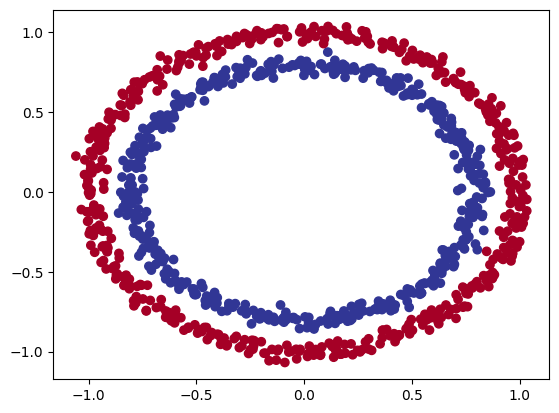

In [9]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu);

**Note** The data er are working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fudamentals.

###1.1 Check input and output shapes

In [10]:
X.shape,y.shape

((1000, 2), (1000,))

In [11]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [12]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


### 1.2 Turn into tensor and create train and test splits

In [13]:
import torch
torch.__version__

'2.6.0+cu124'

In [14]:
type(X),X.dtype

(numpy.ndarray, dtype('float64'))

In [15]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [16]:
type(X),X.dtype,y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [17]:
#split data into training and test sets
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test= train_test_split(X,
                                                y,
                                                test_size=0.2 ,# == 20% test and 80% train,
                                                random_state=42,
                                                )

In [18]:
len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

### 2. Building model

lets build model to classify our blue and red dots

to do so , we want to:
1. Setup device agnostic code so our code will run on an accelerator (GPU) if there is one
2. construct a model (by subclassing nn.Module)
3. Define a loss function and optimizer
4. Create a training and test function

In [19]:
import torch
from torch import nn

In [20]:
## device agnostic code
device = "cpu" if not torch.cuda.is_available() else "cuda"
device

'cpu'

### CONSTRUCTING A MODEL
1. subclass `nn.Module` (almost all model is subclass of `nn.Module`)
2. Create 2 `nn.Linear()` layers that are cappable of handling the shapes of our data
3. Defines a `forward()` method that outlines the forward pass (or forward computation) of the model
4. Instatiate an instance of our model class and send it to the target device

In [21]:
# 1. construct a model that subclass  the 'nn.Module' class
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    #2 create 2 nn.Linear layer capapble of handling classification.
    self.Layer1 =nn.Linear(in_features=2,out_features=5) # takes 2 in and upscale it ot 5 features
    self.Layer2 = nn.Linear(in_features=5,out_features=1) #takes in 5 in and output 1 feature
#define forward method that outlines the forward pass
  def forward(self,x):
    return self.Layer2(self.Layer1(x)) #x -> layer1 -> layer2-> output


#4 instantiate an instance of our model classs and sed it to the target device
model_0 = CircleModelV0().to(device)
model_0



CircleModelV0(
  (Layer1): Linear(in_features=2, out_features=5, bias=True)
  (Layer2): Linear(in_features=5, out_features=1, bias=True)
)

In [22]:
device

'cpu'

In [23]:
next(model_0.parameters()).device

device(type='cpu')

In [24]:
#lets replicate the model abov using nn.Sequential()
model_0 = nn.Sequential(
    nn.Linear(in_features=2,out_features=5),
    nn.Linear(in_features=5,out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [25]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.6658,  0.5922],
                      [-0.6328, -0.1666],
                      [-0.6226, -0.6647],
                      [-0.4798, -0.7066],
                      [-0.2387, -0.5580]])),
             ('0.bias', tensor([-0.6858,  0.4350, -0.3549,  0.2410,  0.2293])),
             ('1.weight', tensor([[0.1316, 0.2144, 0.4433, 0.2911, 0.3099]])),
             ('1.bias', tensor([-0.1835]))])

In [26]:
#make some predictions with model
with torch.inference_mode():
  untrained_preds =model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}")
print(f"Shape of predictions: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}")
print(f"Shape of test samples: {X_test.shape}")
print(f"\n First 10 predictions: \n {untrained_preds[:10]}")
print(f"\n first 10 lables: \n {y_test[:10]}")

Length of predictions: 200
Shape of predictions: torch.Size([200, 1])
Length of test samples: 200
Shape of test samples: torch.Size([200, 2])

 First 10 predictions: 
 tensor([[-0.3600],
        [-0.8134],
        [ 0.5030],
        [-0.6031],
        [-0.0142],
        [-0.2870],
        [-1.1540],
        [-1.0320],
        [ 0.5235],
        [-0.8496]])

 first 10 lables: 
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [27]:
X_test[:10],y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### 2.1 setup loss functiona and optimizer

which loss function to use ?

again... this is problem specific

for example for regression you might want MAE or MSE (mean absolute error or mean squared error )

For classification you might want to use binary cross entropy or categorical cross entropy (cross entropy).

As a reminder loss function is a function which measures how *wrong* is your model

In [28]:
##setup loss function
loss_fn = nn.BCEWithLogitsLoss() #sigmoid function involves


optimizer = torch.optim.SGD(params =model_0.parameters(),
                            lr = 0.1)

In [29]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.6658,  0.5922],
                      [-0.6328, -0.1666],
                      [-0.6226, -0.6647],
                      [-0.4798, -0.7066],
                      [-0.2387, -0.5580]])),
             ('0.bias', tensor([-0.6858,  0.4350, -0.3549,  0.2410,  0.2293])),
             ('1.weight', tensor([[0.1316, 0.2144, 0.4433, 0.2911, 0.3099]])),
             ('1.bias', tensor([-0.1835]))])

In [32]:
# Calculate accuracy - out of 100 examples, what percentage does our model get right?

# def accuracy_fn(y_true,y_pred):
#   correct = torch.eq(y_true,y_pred()).sum().item()
#   acc = (correct/len(y_pred))*100
#   return acc
  # Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates where two tensors are equal
    acc = (correct / len(y_pred)) * 100
    return acc

###3. Training Model
to train our model we need to make a training Loop
1. forward pass
2. calculate loss
3. zero_grad
4. backp propagation
5. optimizer step

# 3.1 Going from raw logits -> prediction probabilities -> prediction labels

Our model outputs are going to be raw logits

we can convert these logits into prediction probabilities by passing them through some kind of activation function (for example sigmoid for binary classification and softmax for multiclass classification)

Then we can convert our models predictio probabilities to prediction labels by either rounding them or taking the argmax().

In [31]:
# View the first 5 outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():

  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.3600],
        [-0.8134],
        [ 0.5030],
        [-0.6031],
        [-0.0142]])

In [32]:
y_test[:5 ]

tensor([1., 0., 1., 0., 1.])

In [33]:
#use the sigmoid activation function on our model logits to turn them into prediction probabilities
y_pred_probs= torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4110],
        [0.3072],
        [0.6232],
        [0.3536],
        [0.4965]])

In [34]:
#find the predicted labels
y_preds = torch.round(y_pred_probs)

#in Full (logits->pred probs->pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

#check for equality
print(torch.eq(y_preds.squeeze(),y_pred_labels.squeeze()))
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 1., 0., 0.])

In [35]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [36]:
### 3.2 Training and testing loops
torch.cuda.manual_seed(42)
epochs=1000
X_train,y_train = X_train.to(device),y_train.to(device)
X_test,y_test = X_test.to(device),y_test.to(device)
for epoch in range(epochs):
   model_0.train()
   #forward pass
   y_logits=model_0(X_train).squeeze()
   y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> probability -> prediction labels
   #loss calculate
   loss = loss_fn(y_logits,y_train)
   #accuracy
   acc= accuracy_fn(y_true=y_train,
                    y_pred=y_pred)
   #optimizer zero_grad
   optimizer.zero_grad()
   #back propagation calculate the gradient
   loss.backward()
   #opitmizer
   optimizer.step()

#for testing
   model_0.eval()
   with torch.inference_mode():
      test_logits = model_0(X_test).squeeze()
      test_preds = torch.round(torch.sigmoid(test_logits))
      test_loss = loss_fn(test_logits,y_test)
      test_acc = accuracy_fn(y_true=y_test,
                            y_pred=test_preds)


#print out whats happening
      if epoch %10 ==0:
        print(f"Epoch:{epoch} | Loss: {loss:.5f},Acc:{acc:.2f}% | test loss: {test_loss:.5f},| tesst acc:{test_acc:.2f}%")




Epoch:0 | Loss: 0.74661,Acc:48.25% | test loss: 0.72470,| tesst acc:53.50%
Epoch:10 | Loss: 0.72648,Acc:48.75% | test loss: 0.70871,| tesst acc:53.50%
Epoch:20 | Loss: 0.71484,Acc:48.88% | test loss: 0.70030,| tesst acc:53.50%
Epoch:30 | Loss: 0.70767,Acc:48.88% | test loss: 0.69573,| tesst acc:53.50%
Epoch:40 | Loss: 0.70304,Acc:48.88% | test loss: 0.69324,| tesst acc:53.50%
Epoch:50 | Loss: 0.69996,Acc:48.88% | test loss: 0.69193,| tesst acc:53.50%
Epoch:60 | Loss: 0.69787,Acc:48.88% | test loss: 0.69132,| tesst acc:53.50%
Epoch:70 | Loss: 0.69643,Acc:48.88% | test loss: 0.69113,| tesst acc:53.50%
Epoch:80 | Loss: 0.69542,Acc:49.00% | test loss: 0.69117,| tesst acc:53.50%
Epoch:90 | Loss: 0.69471,Acc:48.88% | test loss: 0.69136,| tesst acc:53.50%
Epoch:100 | Loss: 0.69421,Acc:48.25% | test loss: 0.69162,| tesst acc:53.00%
Epoch:110 | Loss: 0.69386,Acc:48.12% | test loss: 0.69191,| tesst acc:53.00%
Epoch:120 | Loss: 0.69361,Acc:48.50% | test loss: 0.69220,| tesst acc:53.00%
Epoch:130 

##4. Make predictions and evaluate the model

From the metrics it looks like our model isn't learning anything

so to inspect it lets make some predictions and make them visual!

in other words , "Visualize,Visualize,Visualize!"

In [31]:
import requests
from pathlib import Path
#download helper function from learn pytorch repo (if its not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

from helper_functions import plot_decision_boundary,plot_predictions

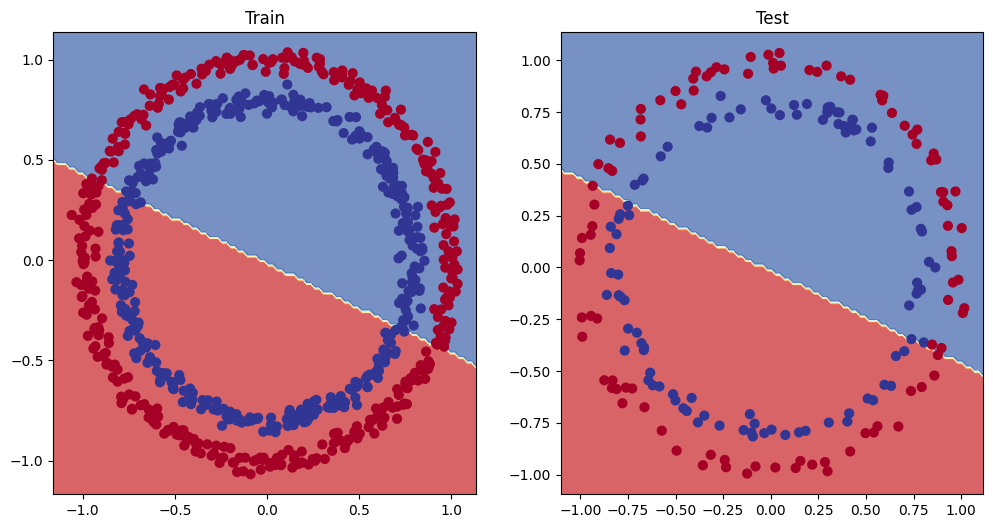

In [38]:
#plot decision noundary of the model
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)


##5 Improving a model( from a model perspective)

* Add more layers - give the model more chances to learn about patterns in the data
* Add more hidden units = go from 5 hidden units to 10 hidden units
* Fit for longer
* changing activation FunctionS
* change the learning rate
* change the loss function

These options are all from a models perspective because theey deal directly with the model, rather than the data.

And because these options are all values we (As machine learning engineers and data scientists) can change , they are referred as **hyperparameters**

In [39]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2,out_features=10)
    self.layer_2 = nn.Linear(in_features=10,out_features=10)
    self.layer_3 = nn.Linear(in_features=10,out_features=1)

  def forward(self,x):
    return self.layer_3(self.layer_2(self.layer_1(x)))


model_1 = CircleModelV1()
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [40]:
# Create a loss function
loss_fn =nn.BCEWithLogitsLoss()

#Create an optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),lr=0.1)

In [41]:
X_train.device

device(type='cpu')

In [42]:
#training and evaluation loop for model_1
torch.manual_seed(42)

torch.cuda.manual_seed(42)
epochs =1000
model_1.to(device)
X_train,y_train=X_train.to(device),y_train.to(device)
X_test,y_test=X_test.to(device),y_test.to(device)

for epoch in range(epochs):
  model_1.train()
  #forward pass
  y1_logits_ = model_1(X_train).squeeze()
  y1_preds = torch.round(torch.sigmoid(y1_logits_))
  #loss_fn
  loss1= loss_fn(y1_logits_,y_train)
  acc =accuracy_fn(y_true=y_train,
                   y_pred = y_pred)
  #zero_gradient
  optimizer.zero_grad()
  #back propagation
  loss1.backward()
  #optimizer
  optimizer.step()

  model_1.eval()
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))
    #cal loss
    test_loss = loss_fn(test_logits,
                        test_preds)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred = test_preds)

  #print out whats happening
  if epoch %100 ==0:
    print(f"Epoch:{epoch} | Loss: {loss1:.5f},Acc:{acc:.2f}% | test loss: {test_loss:.5f},| test acc:{test_acc:.2f}%")


Epoch:0 | Loss: 0.69670,Acc:51.00% | test loss: 0.62081,| test acc:48.00%
Epoch:100 | Loss: 0.69324,Acc:51.00% | test loss: 0.66399,| test acc:48.00%
Epoch:200 | Loss: 0.69305,Acc:51.00% | test loss: 0.67412,| test acc:48.50%
Epoch:300 | Loss: 0.69301,Acc:51.00% | test loss: 0.67669,| test acc:46.00%
Epoch:400 | Loss: 0.69299,Acc:51.00% | test loss: 0.67718,| test acc:47.00%
Epoch:500 | Loss: 0.69299,Acc:51.00% | test loss: 0.67705,| test acc:47.50%
Epoch:600 | Loss: 0.69298,Acc:51.00% | test loss: 0.67682,| test acc:47.00%
Epoch:700 | Loss: 0.69298,Acc:51.00% | test loss: 0.67664,| test acc:46.50%
Epoch:800 | Loss: 0.69298,Acc:51.00% | test loss: 0.67650,| test acc:46.00%
Epoch:900 | Loss: 0.69298,Acc:51.00% | test loss: 0.67640,| test acc:46.00%


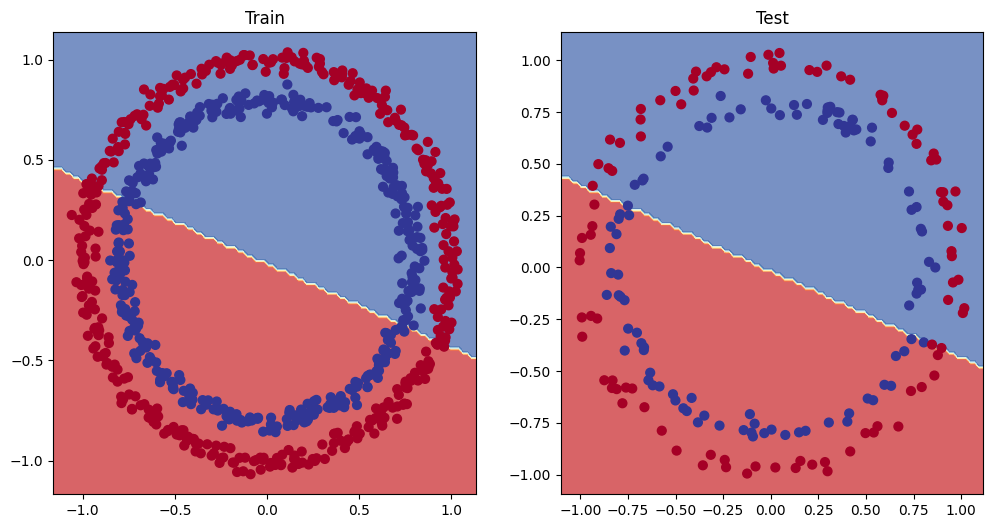

In [43]:
#plot the decision boundary
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1,X_test,y_test)

##5.1 checking if our model learn anything of any type

one way to troubleshoot to a larger problem is to set out a smaller problem

In [44]:
weight =0.7
bias =0.3
start =0
stop =1
step=0.01

X_reg = torch.arange(start,stop,step).unsqueeze(dim=1)
y_reg=weight*X_reg + bias

X_reg[:5],y_reg[:5]

(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [45]:
train_split = int(len(X_reg)*0.8)
X_train_reg,y_train_reg = X_reg[:train_split],y_reg[:train_split]
X_test_reg,y_test_reg = X_reg[train_split:],y_reg[train_split:]
len(X_train_reg),len(X_test_reg )


(80, 20)

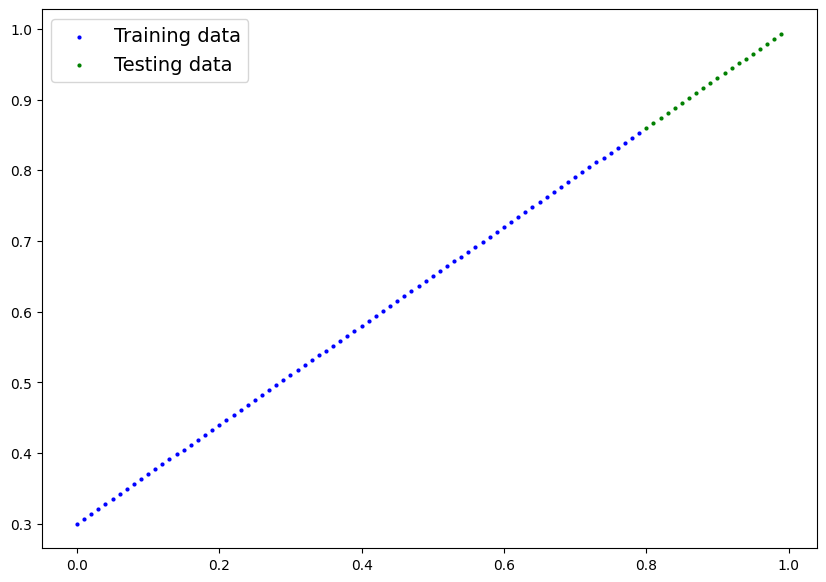

In [46]:
plot_predictions(train_data=X_train_reg,
                 train_labels = y_train_reg,
                 test_data = X_test_reg,
                 test_labels = y_test_reg)

In [47]:
model_testing = CircleModelV1()
model_testing

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

##5.2 need to adjust model to fit straight line

In [48]:
#same architecture as model_1(but using nn.Sequential())
model_2 = nn.Sequential(
    nn.Linear(in_features=1,out_features=10),
    nn.Linear(in_features=10,out_features=10),
    nn.Linear(in_features=10,out_features=1)
).to(device)
model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [49]:
#loss and optimizer
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params =model_2.parameters(),
                            lr=0.01)

In [50]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs=1000
model_2.to(device)
X_train_reg,y_train_reg = X_train_reg.to(device),y_train_reg.to(device)
X_test_reg,y_test_reg = X_test_reg.to(device),y_test_reg.to(device)
#training
for epoch in range (epochs):
  model_2.train()
  #forward pass
  y_pred_reg = model_2(X_train_reg)
  #loss cal
  loss_val_testing_model = loss_fn(y_pred_reg,y_train_reg)
  #zero grad
  optimizer.zero_grad()
  #back propagation
  loss_val_testing_model.backward()
  #optimizer
  optimizer.step()

#testing
  model_2.eval()
  with torch.inference_mode():
    test_pred_reg = model_2(X_test_reg)
    test_loss_reg = loss_fn(test_pred_reg , y_test_reg)

  #print out what is happening
  if epoch %100==0:
    print(f"Epoch:{epoch} | loss : {loss_val_testing_model:.5f} | test_loss : {test_loss_reg:.5f}")


Epoch:0 | loss : 0.57896 | test_loss : 0.82273
Epoch:100 | loss : 0.03496 | test_loss : 0.00156
Epoch:200 | loss : 0.03268 | test_loss : 0.00330
Epoch:300 | loss : 0.02942 | test_loss : 0.00446
Epoch:400 | loss : 0.02731 | test_loss : 0.00570
Epoch:500 | loss : 0.02672 | test_loss : 0.00534
Epoch:600 | loss : 0.02627 | test_loss : 0.00511
Epoch:700 | loss : 0.02594 | test_loss : 0.00496
Epoch:800 | loss : 0.02482 | test_loss : 0.00394
Epoch:900 | loss : 0.02333 | test_loss : 0.00462


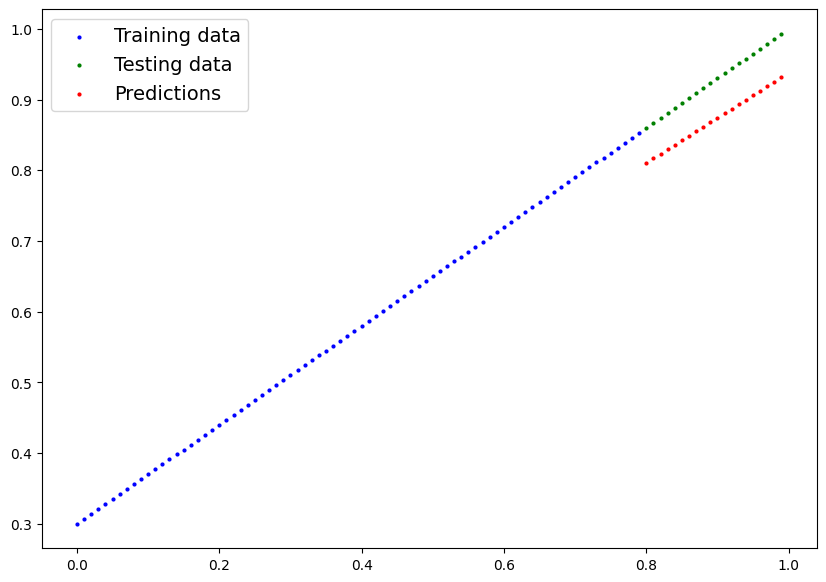

In [51]:
#making some predictions
model_2.eval()
with torch.inference_mode():
  y_pred_regs= model_2(X_test_reg)
  loss_value_reg = loss_fn(y_pred_regs,y_test_reg)

plot_predictions(train_data = X_train_reg.cpu(),
                  train_labels = y_train_reg.cpu(),
                  test_data = X_test_reg.cpu(),
                  test_labels = y_test_reg.cpu(),
                  predictions=y_pred_regs.cpu(),
                  )

In [7]:
##deevicee agnostic code
device="cpu" if not torch.cuda.is_available() else "cuda"
device

'cpu'

# 6. The missing piece : non-Linearity

"What patterns could you build if u were given an infinte amount of a straight and non-straight lines ?"

Or in machine learning terms , an infinte (but really it is finite) of linear and non-linear functions.

# 6.1 Recreating non-linear data (red and blue circles)

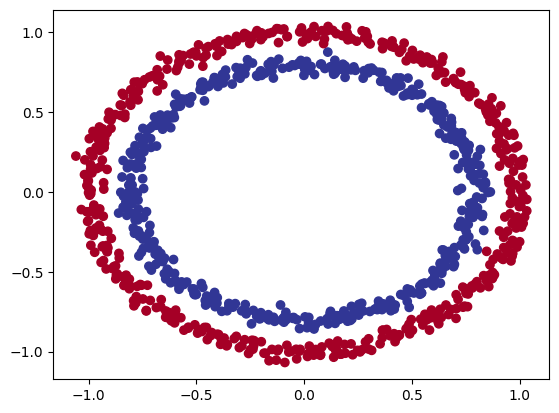

In [8]:
# make and plot data
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
n_samples =1000
X,y = make_circles(n_samples,
                   noise=0.03,
                   random_state=42)
plt.scatter(X[:,0],X[:,1],c=y,cmap=plt.cm.RdYlBu)



In [9]:
 # Convert data to tensors and then to train and test splits
import torch
from sklearn.model_selection import train_test_split
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)
X_train,X_test,y_train,y_test = train_test_split(X,
                                                  y,
                                                  test_size=0.2,
                                                  random_state=42)
X_train[:5],y_train[:5]

(tensor([[ 0.6579, -0.4651],
         [ 0.6319, -0.7347],
         [-1.0086, -0.1240],
         [-0.9666, -0.2256],
         [-0.1666,  0.7994]]),
 tensor([1., 0., 0., 0., 1.]))

### 6.2 Building a model with non linearity

* linear = straight line
* no linear = curves

Artificial neural networks are a large combination of linear (straight) and non-straight (non -linear) functions which are potentially able to find patterns in data

In [10]:
# build a model with non linear activation function
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer1 = nn.Linear(in_features=2,out_features=10)
    self.layer2 = nn.Linear(in_features=10,out_features=10)
    self.layer3 = nn.Linear(in_features=10,out_features=1)
    self.relu = nn.ReLU()

  def forward(self,x):
    #where should we place a non-linear functions?
    return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

model_3=CircleModelV2()
model_3

CircleModelV2(
  (layer1): Linear(in_features=2, out_features=10, bias=True)
  (layer2): Linear(in_features=10, out_features=10, bias=True)
  (layer3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [11]:
#loss_function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
optimizer =torch.optim.SGD(params =model_3.parameters(),
                           lr=0.1)

## 6.3 training a model with non-linearity

In [22]:
#train and testing model
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs = 2000
model_3.to(device)
X_train,y_train = X_train.to(device),y_train.to(device)
X_test,y_test = X_test.to(device),y_test.to(device)
for epoch in range(epochs):
  #training code
  model_3.train()
  #forward pass
  y_logits = model_3(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))
  #loss cal
  loss_value = loss_fn(y_logits,y_train)
  acc = accuracy_fn(y_true=y_train,
                    y_pred=y_preds)
  #zero grad
  optimizer.zero_grad()
  #back propagation
  loss_value.backward()
  #optimizer
  optimizer.step()

  #testing
  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))
    test_loss  =loss_fn(test_logits,y_test)
    test_acc = accuracy_fn(y_true=y_test,
                           y_pred=test_preds)
  #what is happening
  if epoch%100  ==0:
    print(f"Epoch: {epoch} | loss: {loss_value:.4f} | accuracy: {acc:.2f}% | test loss: { test_loss:.4f} | test accuracy: {test_acc:.2f}")


Epoch: 0 | loss: 0.4815 | accuracy: 93.50% | test loss: 0.4993 | test accuracy: 90.50
Epoch: 100 | loss: 0.3706 | accuracy: 97.75% | test loss: 0.4059 | test accuracy: 92.00
Epoch: 200 | loss: 0.2546 | accuracy: 99.00% | test loss: 0.3033 | test accuracy: 96.50
Epoch: 300 | loss: 0.1718 | accuracy: 99.50% | test loss: 0.2211 | test accuracy: 97.50
Epoch: 400 | loss: 0.1219 | accuracy: 99.62% | test loss: 0.1651 | test accuracy: 99.00
Epoch: 500 | loss: 0.0912 | accuracy: 99.88% | test loss: 0.1274 | test accuracy: 99.50
Epoch: 600 | loss: 0.0710 | accuracy: 99.88% | test loss: 0.1032 | test accuracy: 99.50
Epoch: 700 | loss: 0.0577 | accuracy: 99.88% | test loss: 0.0867 | test accuracy: 99.50
Epoch: 800 | loss: 0.0485 | accuracy: 99.88% | test loss: 0.0747 | test accuracy: 99.50
Epoch: 900 | loss: 0.0418 | accuracy: 99.88% | test loss: 0.0658 | test accuracy: 100.00
Epoch: 1000 | loss: 0.0363 | accuracy: 99.88% | test loss: 0.0598 | test accuracy: 100.00
Epoch: 1100 | loss: 0.0320 | ac

### 6.4 Evaluation a model trained with non-linear activation function

In [23]:
##making predictions

model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test))).squeeze()
y_preds[:10],y_test[:10]



(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

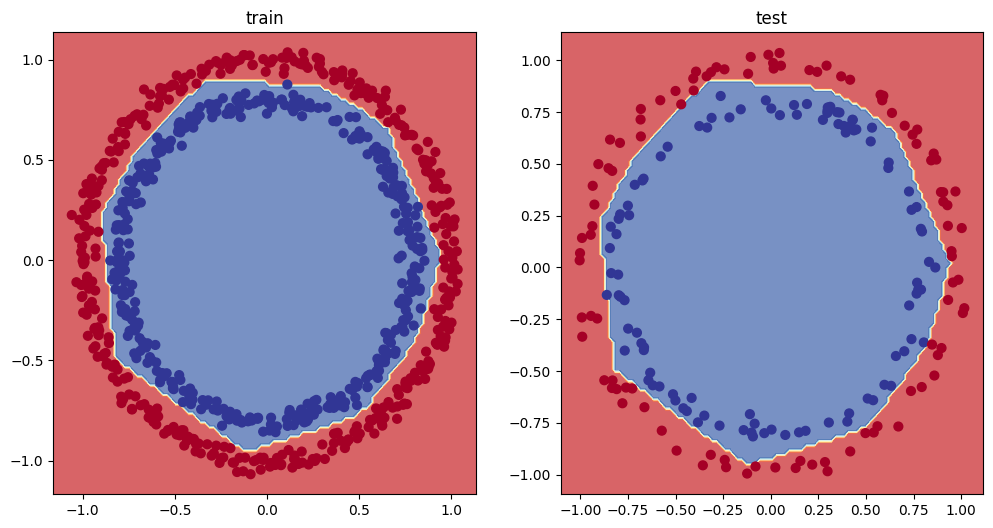

In [24]:
#plot decision boundaries
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("train")
plot_decision_boundary(model_3,X_train,y_train)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_3,X_test,y_test)

### 7. Replicating non-linear activation functions
Neural network, rather than us telling the model what to learn, we give it the tools to discover patterns in data and it tries to figure out the patterns on its own.

And these tools are linear and non linear functions

In [29]:
#create a tensor
A= torch.arange(-10,10,1,dtype=torch.float32)
A.dtype

torch.float32

In [30]:
A


tensor([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,   1.,
          2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.])

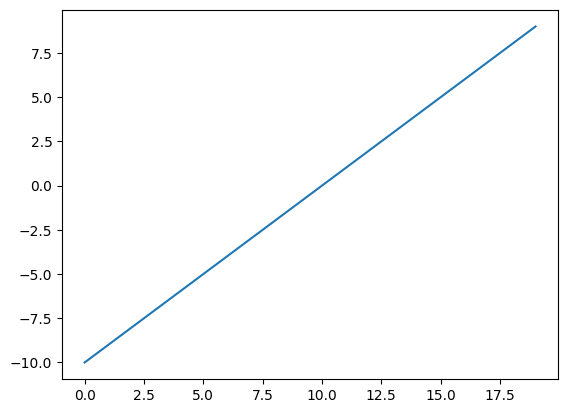

In [31]:
plt.plot(A)

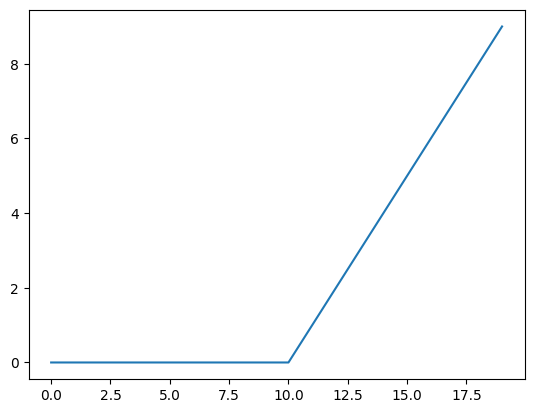

In [32]:
plt.plot(torch.relu(A))

In [36]:
def relu(x: torch.Tensor)->torch.Tensor:
  return torch.max(torch.tensor(0),x)

relu(A)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 3., 4., 5., 6., 7.,
        8., 9.])

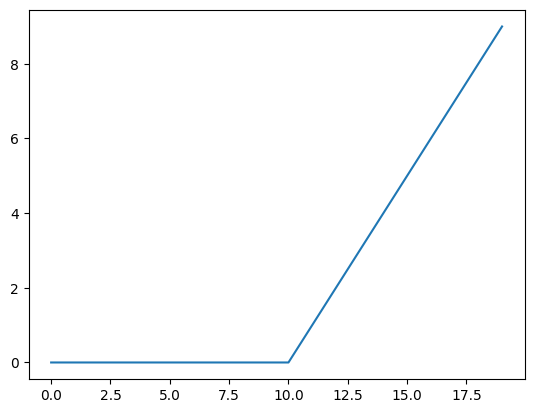

In [37]:
plt.plot(relu(A))

In [41]:
# Now lets do the same for sigmoid
def sigmoid(x):
  return 1/(1+torch.exp(-x))


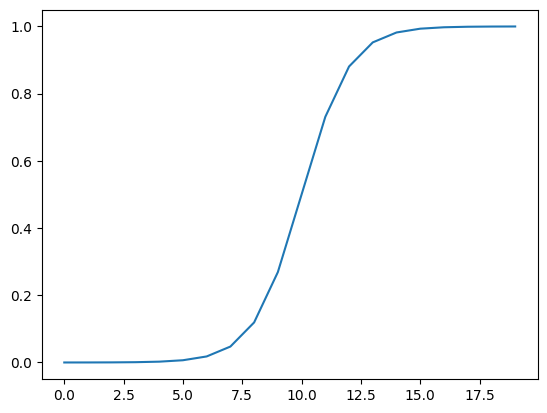

In [39]:
plt.plot(torch.sigmoid(A))

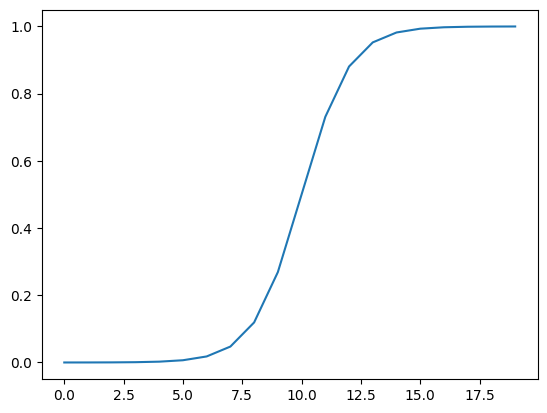

In [42]:
plt.plot(sigmoid(A))

### 8. Putting it all together with a multi-class classification problem

* Binary classification = one thing or another (cat vs dog , spam v not spam, fraud or not fraud).
* Multi-class classfication = more than one thing or another (cat vs dog vs chicken).

# 8.1 Creating a toy multi-class dataset

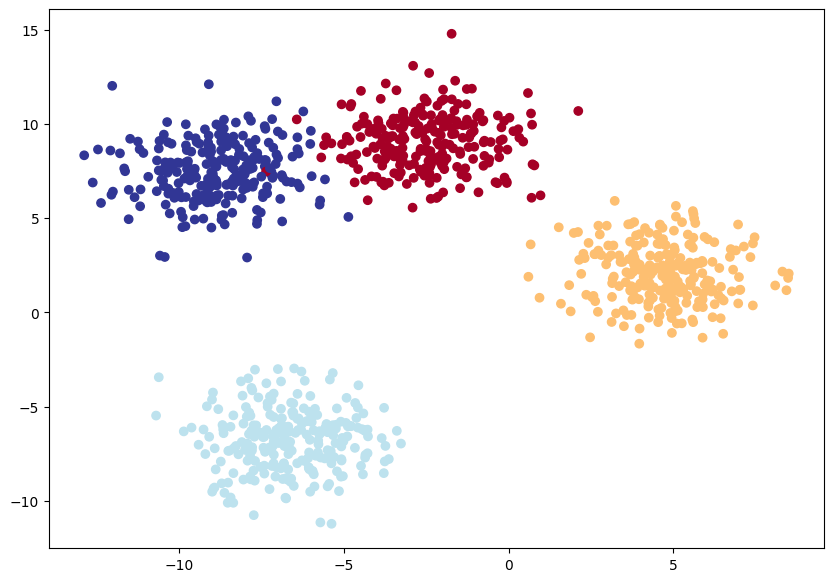

In [21]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

#set the hyperparametrs for data creation
NUM_CLASSES= 4
NUM_FEATURES =2
RANDOM_SEED = 42

# 1. Create multi-class data
X_blob,y_blob =make_blobs(n_samples=1000,
                         n_features=NUM_FEATURES,
                         centers = NUM_CLASSES,
                         cluster_std=1.5,
                         random_state=RANDOM_SEED)

#2 turn data into tensors
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

# 3. split into train and test
X_blob_train,X_blob_test,y_blob_train,y_blob_test = train_test_split(X_blob,
                                                                     y_blob,
                                                                     test_size=0.2,
                                                                     random_state = RANDOM_SEED)
#4 plot data (visualize)
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0],X_blob[:,1],c=y_blob,cmap=plt.cm.RdYlBu)

In [22]:
X_blob_train

tensor([[ 5.0405,  3.3076],
        [-2.6249,  9.5260],
        [-8.5240, -9.0402],
        ...,
        [-1.7366,  9.7850],
        [-6.8139, -7.1006],
        [-9.0311,  4.5007]])

## 8.2 Building a multi-class classificatio model in pytorch

In [23]:
##create device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [47]:
# Build multiclass classification model
class BlobModel(nn.Module):
  def __init__(self,input_features,output_features,hidden_units=8):
    """ intializes multi-class classification model
    Args:
     input_features (int): Number of input features to the model
     output_features (int): Number of output features(number of output classes)
     hidden_units (int): Number of hidden units between layers,default=8
     """
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=input_features,out_features=hidden_units),
        # nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=hidden_units),
        # nn.ReLU(),
        nn.Linear(in_features=hidden_units,out_features=output_features)
    )

  def forward(self,x):
    return self.linear_layer_stack(x)
model_4 = BlobModel(input_features=2,output_features=4,hidden_units=8)
model_4.to(device)

BlobModel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): Linear(in_features=8, out_features=8, bias=True)
    (2): Linear(in_features=8, out_features=4, bias=True)
  )
)

#8.3 loss_function and optimizer for multi-class classification model


In [48]:
#loss_fn and optimizer
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_4.parameters(),
                            lr=0.1)

### 8.4 Getting prediction probabilities for a multi-class PyTorch model

In order to evaluate and train and test our model, we need to convert our models outputs (logits) to prediction probabilities and then to prediction labels

Logits -> Pred prob(use softmax) -> Pred labels(use argmax)

In [49]:
model_4.eval()
model_4.to(device)
with torch.inference_mode():
  y_preds_logits=model_4(X_blob_test.to(device))
y_preds_logits[:5]


tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]], device='cuda:0')

In [50]:
#convert our models logits to prediction probabilities

y_pred_probs = torch.softmax(y_preds_logits,dim=1)
print(y_pred_probs[:5])
print(y_preds_logits[:5])


tensor([[0.1872, 0.2918, 0.1495, 0.3715],
        [0.2824, 0.0149, 0.2881, 0.4147],
        [0.3380, 0.0778, 0.4854, 0.0989],
        [0.2118, 0.3246, 0.1889, 0.2748],
        [0.1945, 0.0598, 0.1506, 0.5951]], device='cuda:0')
tensor([[-1.2549, -0.8112, -1.4795, -0.5696],
        [ 1.7168, -1.2270,  1.7367,  2.1010],
        [ 2.2400,  0.7714,  2.6020,  1.0107],
        [-0.7993, -0.3723, -0.9138, -0.5388],
        [-0.4332, -1.6117, -0.6891,  0.6852]], device='cuda:0')


In [51]:
# convert our models pred prob to pred labels
y_preds=torch.argmax(y_pred_probs,dim=1)
y_preds

tensor([3, 3, 2, 1, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 3, 3, 3, 2, 3, 3, 3, 3, 3, 2,
        2, 2, 3, 3, 3, 3, 3, 1, 1, 2, 1, 2, 1, 3, 3, 2, 3, 3, 3, 2, 3, 3, 3, 3,
        3, 3, 1, 3, 3, 1, 3, 2, 3, 1, 3, 2, 2, 3, 3, 2, 2, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 3, 3, 2, 3, 3, 3, 3, 2, 3, 1, 3, 3, 2, 1, 1, 3, 2, 2, 3, 3, 3, 1, 2,
        2, 3, 3, 1, 2, 3, 3, 3, 2, 3, 3, 2, 3, 2, 3, 3, 3, 3, 3, 1, 1, 3, 2, 2,
        2, 2, 3, 3, 3, 2, 2, 1, 3, 2, 3, 3, 3, 3, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3,
        2, 2, 2, 3, 3, 1, 1, 1, 1, 1, 3, 1, 3, 2, 2, 3, 2, 2, 3, 3, 2, 2, 3, 3,
        1, 3, 2, 3, 3, 1, 2, 3], device='cuda:0')

In [52]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1], device='cuda:0')

### 8.5 Creating a training loop and testing loop for a multi-class model

In [53]:
# training and testing
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs =100
X_blob_train,y_blob_train=X_blob_train.to(device),y_blob_train.to(device)
X_blob_test,y_blob_test=X_blob_test.to(device),y_blob_test.to(device)

for epoch in range(epochs):
  model_4.train()
  #forward pass
  y_logits = model_4(X_blob_train)
  y_preds = torch.softmax(y_logits,dim=1).argmax(dim=1)
  #loss cal
  loss_val = loss_fn(y_logits,y_blob_train)
  acc = accuracy_fn(y_true = y_blob_train,
                    y_pred = y_preds)
  #zero grad
  optimizer.zero_grad()
  #back propagation
  loss_val.backward()
  #optimizer
  optimizer.step()

  #testing
  model_4.eval()
  with torch.inference_mode():
    y_test_logits= model_4(X_blob_test)
    y_test_preds =torch.softmax(y_test_logits,dim=1).argmax(dim=1)
    test_loss = loss_fn(y_test_logits,y_blob_test)
    test_acc = accuracy_fn(y_true=y_blob_test,
                           y_pred=y_test_preds)

  # whats happening
  if epoch%10 ==0:
    print(f"Epoch:{epoch} | loss:{loss_val:.5f}| acc :{acc:.2f}% | test_loss:{test_loss:.2f} | test_Acc:{test_acc:.2f}%  ")


Epoch:0 | loss:1.04324| acc :65.50% | test_loss:0.58 | test_Acc:95.50%  
Epoch:10 | loss:0.14398| acc :99.12% | test_loss:0.13 | test_Acc:99.00%  
Epoch:20 | loss:0.08062| acc :99.12% | test_loss:0.07 | test_Acc:99.50%  
Epoch:30 | loss:0.05924| acc :99.12% | test_loss:0.05 | test_Acc:99.50%  
Epoch:40 | loss:0.04892| acc :99.00% | test_loss:0.04 | test_Acc:99.50%  
Epoch:50 | loss:0.04295| acc :99.00% | test_loss:0.03 | test_Acc:99.50%  
Epoch:60 | loss:0.03910| acc :99.00% | test_loss:0.03 | test_Acc:99.50%  
Epoch:70 | loss:0.03643| acc :99.00% | test_loss:0.03 | test_Acc:99.50%  
Epoch:80 | loss:0.03448| acc :99.00% | test_loss:0.03 | test_Acc:99.50%  
Epoch:90 | loss:0.03300| acc :99.12% | test_loss:0.02 | test_Acc:99.50%  


### 8.6 making and evaluating with pytorch multi-class model

In [54]:
model_4.eval()
with torch.inference_mode():
  y_logit = model_4(X_blob_test)
  y_pred = torch.softmax(y_logit,dim=1).argmax(dim=1)
y_pred == y_test_preds

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, Tr

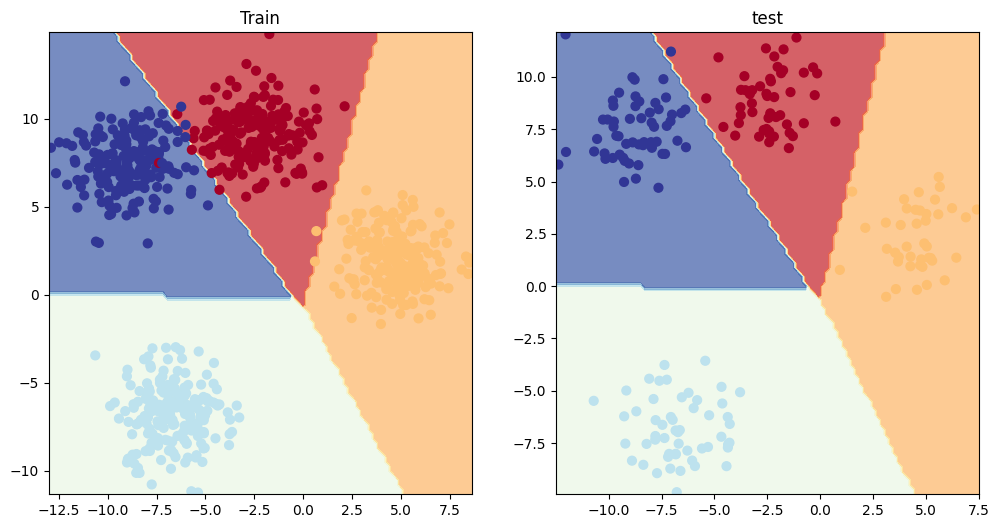

In [55]:
#visualizing
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4,X_blob_train,y_blob_train)
plt.subplot(1,2,2)
plt.title("test")
plot_decision_boundary(model_4,X_blob_test,y_blob_test)

## 9. A few more classification metrices ..(to evalute our classification model)

* Accuracy - out of 100 sample,how many does our model get right
* precision
* recall
* F1-score
* confusion matrix
* classification report


In [57]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 960.9/960.9 kB 60.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 111.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 55.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 92.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [64]:
from torchmetrics import Accuracy

#setupt metric
torchmetric_accuracy = Accuracy(task="multiclass",num_classes=4).to(device)

# Calculate accuracy
torchmetric_accuracy(y_test_preds,y_blob_test)

tensor(0.9950, device='cuda:0')

In [66]:
from torchmetrics import Recall
torchmetric_recall = Recall(task="multiclass", num_classes=4).to(device)

torchmetric_recall(y_test_preds,y_blob_test)

tensor(0.9950, device='cuda:0')